In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("C:/Users/Emil/Downloads/Midterm data.csv")

In [14]:
print(df.head())
print(df.info())

   Unnamed: 0         ID     Sex Marital status   Age    Education    Income  \
0           0  100000001    Male         Single  90.0   University  124670.0   
1           1  100000002  Female     Non-single  22.0  High school  150773.0   
2           2  100000003    Male         Single  49.0  High school   89210.0   
3           3  100000004    Male         Single  45.0  High school  171565.0   
4           4  100000005    Male          Sinle  53.0  High school  149031.0   

                  Occupation Settlement size  
0  Skilled employee/Official        Big city  
1  Skilled employee/Official        Big city  
2                 Unemployed      Small city  
3  Skilled employee/Official  Mid-sized city  
4  Skilled employee/Official  Mid-sized city  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2000 non-null   i

In [15]:
#We should do datapreprocessing.Therefore we define the number of null values

In [16]:
column_nan_count = df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
Unnamed: 0           0
ID                   0
Sex                  0
Marital status      19
Age                 67
Education           36
Income             273
Occupation          12
Settlement size     13
dtype: int64


In [17]:
#In here I clean outlier values. I assume that there exist any person greater than 120 and less than 18. If exists I delete this row
# Also I can fill these rows with mean or mean. But I prefer that method
MIN_AGE = 18
MAX_AGE = 120

df = df[((df['Age'] >= MIN_AGE) & (df['Age'] <= MAX_AGE)) | df['Age'].isna()].copy()

In [18]:
#Then I compute skewness
column_skewness = df.skew(numeric_only=True) 
print("Skewness for each column:")
print(column_skewness)

Skewness for each column:
Unnamed: 0   -0.001687
ID           -0.001687
Age           1.038526
Income        1.706395
dtype: float64


In [19]:
#Skewness is not close to zero. Therefore I fill with median values for each column
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Income'] = df['Income'].fillna(df['Income'].median())

In [20]:
# Now we calculate null values for each column and test the result
column_nan_count = df.isnull().sum()
print("NaN count per column:")
print(column_nan_count)

NaN count per column:
Unnamed: 0          0
ID                  0
Sex                 0
Marital status     19
Age                 0
Education          36
Income              0
Occupation         12
Settlement size    13
dtype: int64


In [21]:
#Now I define unique values for 'Marital status' column. Because maybe some categories can be write incorrectly
unique_values = df['Marital status'].unique()
print(unique_values)

# Count how many unique values
print(f"Number of unique values: {len(unique_values)}")

['Single' 'Non-single' 'Sinle' 'Married' nan 'Non-singl']
Number of unique values: 6


In [22]:
# We can see some values has written false. Therefore I define 2 category 'Married' and 'Single'

df['Marital status'] = df['Marital status'].replace({
    'Sinle': 'Single',          
    'Non-singl': 'Married', 
    'Non-single': 'Married',   
    'Married': 'Married'      
})

unique_values = df['Marital status'].unique()
print(unique_values)

print(f"Number of unique values: {len(unique_values)}")

['Single' 'Married' nan]
Number of unique values: 3


In [23]:
# Fill with mode this column 'Marital status'
df['Marital status'] = df['Marital status'].fillna(df['Marital status'].mode()[0])

In [24]:
column_nan_count = df.isnull().sum()
print("NaN for per column:")
print(column_nan_count)

NaN for per column:
Unnamed: 0          0
ID                  0
Sex                 0
Marital status      0
Age                 0
Education          36
Income              0
Occupation         12
Settlement size    13
dtype: int64


In [25]:
#Now I define unique values for 'Education' column. Because maybe some categories can be write incorrectly
unique_values = df['Education'].unique()
print(unique_values)

['University' 'High school' 'Unknown' nan 'Graduate school']


In [26]:
# Firstly, Replace 'Unknown' with NaN,then fill them via mode
df['Education'] = df['Education'].replace('Unknown', np.nan)

mode_value = df['Education'].mode()[0]
print(f"\nMode (most common value): {mode_value}")

df['Education'] = df['Education'].fillna(mode_value)



Mode (most common value): High school


In [27]:
#Now I define unique values for 'Occupation' column. Because maybe some categories can be write incorrectly
column_nan_count = df.isnull().sum()
print("NaN count per column:")
print(column_nan_count)
# Get unique values
unique_values = df['Occupation'].unique()
print(unique_values)

# Count how many unique values
print(f"Number of unique values: {len(unique_values)}")

NaN count per column:
Unnamed: 0          0
ID                  0
Sex                 0
Marital status      0
Age                 0
Education           0
Income              0
Occupation         12
Settlement size    13
dtype: int64
['Skilled employee/Official' 'Unemployed'
 'Management/High qualified employee' nan]
Number of unique values: 4


In [28]:
# Fill NaN with mode for 'Occupation' column
df['Occupation'] = df['Occupation'].fillna(df['Occupation'].mode()[0])

In [29]:
# Fill NaN with mode for 'Settlement size' column
df['Settlement size'] = df['Settlement size'].fillna(df['Settlement size'].mode()[0])


In [30]:
column_nan_count = df.isnull().sum()
print("NaN for per column:")
print(column_nan_count)

NaN for per column:
Unnamed: 0         0
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64


In [31]:
"""
    I assume that I have finished data preprocessing
"""

'\n    I assume that I have finished data preprocessing\n'

In [32]:
print(df.head())
print(df.info())

   Unnamed: 0         ID     Sex Marital status   Age    Education    Income  \
0           0  100000001    Male         Single  90.0   University  124670.0   
1           1  100000002  Female        Married  22.0  High school  150773.0   
2           2  100000003    Male         Single  49.0  High school   89210.0   
3           3  100000004    Male         Single  45.0  High school  171565.0   
4           4  100000005    Male         Single  53.0  High school  149031.0   

                  Occupation Settlement size  
0  Skilled employee/Official        Big city  
1  Skilled employee/Official        Big city  
2                 Unemployed      Small city  
3  Skilled employee/Official  Mid-sized city  
4  Skilled employee/Official  Mid-sized city  
<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       1998 non-null   int64 

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [34]:
# I select columns which I use them for clustering except ID. Because it is not important. Then I create a copy of df
clustering_columns = ['Age', 'Income', 'Education', 'Settlement size', 
                      'Marital status', 'Occupation', 'Sex']
df_cluster = df[clustering_columns].copy()

In [35]:
# I select categorical columns in order to encoding
le = LabelEncoder()
categorical_cols = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']

In [36]:
# I do encoding via for loop. But I use python libraries
for col in categorical_cols:
    df_cluster[col + '_encoded'] = le.fit_transform(df_cluster[col])

In [37]:
features_for_clustering = ['Age', 'Income', 
                           'Education_encoded', 'Settlement size_encoded',
                           'Marital status_encoded', 'Occupation_encoded']

In [38]:
X = df_cluster[features_for_clustering]

In [39]:
# I do scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
kmeans = KMeans(n_clusters=2, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

In [41]:
df['cluster'] = df_cluster['cluster']

In [42]:
print(df.groupby('cluster')[['Age', 'Income']].mean())

               Age         Income
cluster                          
0        53.256849  142342.280822
1        32.877491  115890.950176


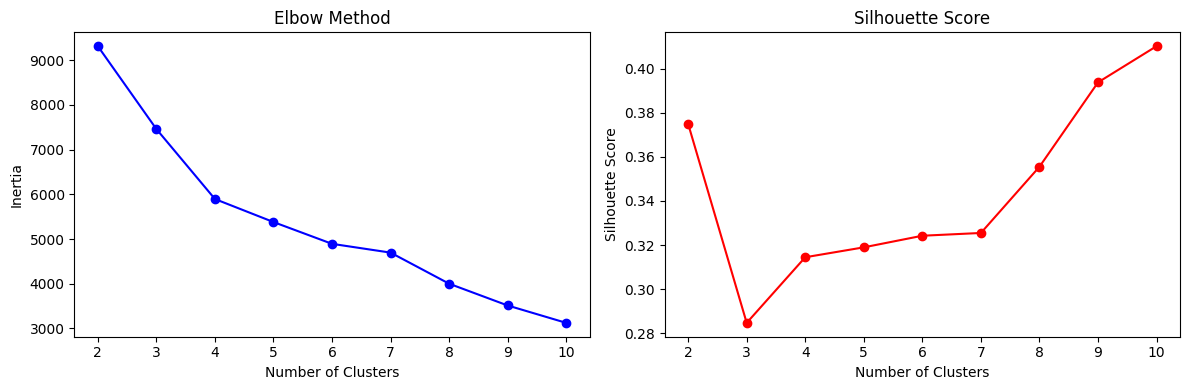

In [43]:
#I vizualize the Elbow method and silhouette score
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled) 
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, clusters))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

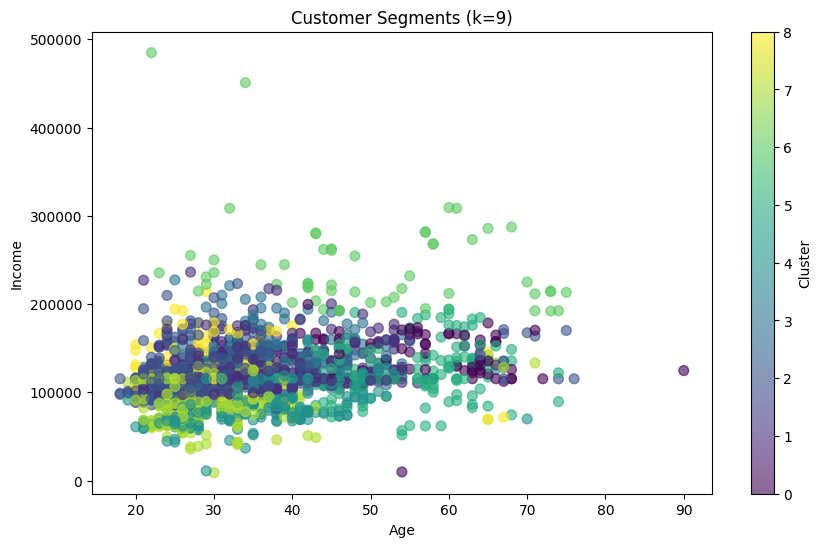


📊 Cluster Profiles:
               Age                      Income                
              mean median count           mean    median count
cluster                                                       
0        54.784810   55.0    79  139844.050633  136812.0    79
1        35.725849   35.0   383  126112.924282  118656.0   383
2        29.896296   28.0   405  120028.701235  115403.0   405
3        36.394850   35.0   233  134730.163090  129630.0   233
4        34.827465   35.0   284   91404.059859   88775.0   284
5        52.370787   52.0   178  122141.264045  115403.0   178
6        49.250000   46.0    56  242887.517857  223324.0    56
7        29.245614   27.0   228   87309.750000   86397.0   228
8        28.960526   28.0   152  123111.861842  115403.0   152


In [44]:
# According to Silhouette Score and Elbow Meth, I select 9 as the optimal number of classes
optimal_k = 9 

# Re-run your clustering with optimal k
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42)
df_cluster['cluster'] = kmeans_optimal.fit_predict(X_scaled)
df['cluster'] = df_cluster['cluster']

# Visualize the result
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Income'], c=df['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title(f'Customer Segments (k={optimal_k})')
plt.colorbar(label='Cluster')
plt.show()

# See cluster characteristics
print("\n📊 Cluster Profiles:")
print(df.groupby('cluster')[['Age', 'Income']].agg(['mean', 'median', 'count']))

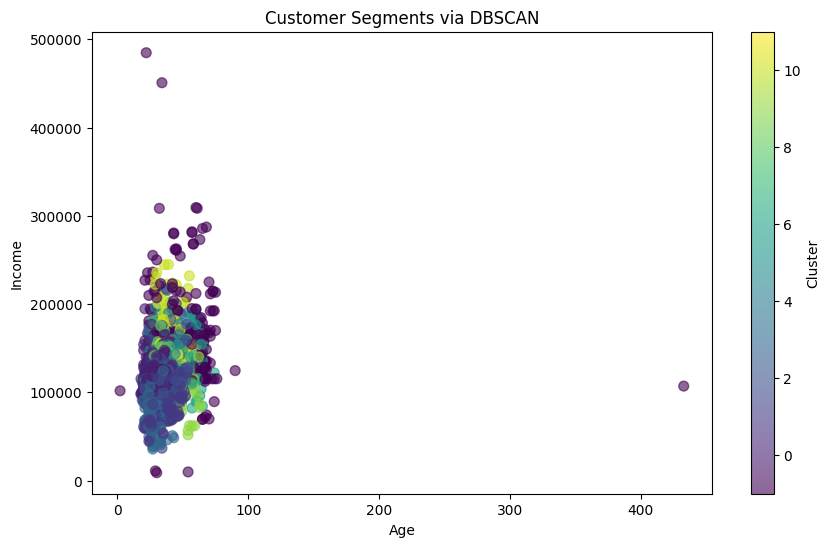

Number of clusters found: 13
Number of noise points: 207


In [169]:
# Now I will apply DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


dbscan = DBSCAN(eps=1, min_samples=20)
df_cluster['cluster'] = dbscan.fit_predict(X_scaled)


df['cluster'] = df_cluster['cluster']

# Vizualization
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Income'], c=df['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Customer Segments via DBSCAN')
plt.colorbar(label='Cluster')
plt.show()

n_clusters = len(set(df_cluster['cluster'])) - (1 if -1 in df_cluster['cluster'] else 0)

n_noise = list(df_cluster['cluster']).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")
